# Advanced Machine Learning — Lab 5
## Data Streams, Concept Drift & Active Learning

**Full name :** Djouaher Yasmine

**Group :** SID1

> **Duration:** 2–3 hours | **Libraries:** numpy · scikit-learn · matplotlib · river (optional)

---

### Learning Objectives
1. Generate and visualize a SEA stream with concept drift
2. Compare a static model to an adaptive model (sliding window)
3. Implement **Page-Hinkley**, **DDM**, and **ADWIN** detectors
4. Build a weighted **adaptive ensemble**
5. Apply **Active Learning** on a stream with a label budget
6. Evaluate with the **prequential** protocol (test-then-train)
7. Use the **River** framework for data streams

---

### Key Formulas

**PHT** — Drift detected when $M_T - U_T > \lambda$, with
$U_T = \sum_{t=1}^T(x_t - \bar{x}_T - \delta)$, $M_T = \max_{t \le T} U_t$

**DDM** — Drift if $p_i + s_i \ge p_{\min} + 3s_{\min}$, warning if $\ge p_{\min} + 2s_{\min}$

**ADWIN** — Drift if $|\bar{\mu}_{W_0} - \bar{\mu}_{W_1}| \ge \sqrt{\dfrac{\ln(4n/\delta)}{2m}}$

**Prequential** — test first, then train on each example

**Active Learning** — query $y_t$ if $u_t = 1 - 2|p_t - 0.5| \ge \tau$ under budget $\sum q_t \le B$


## Part 0 — Setup & Imports

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
from dataclasses import dataclass
from typing import Optional, Tuple, List

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def rolling_mean(x, w):
    c = np.cumsum(np.insert(x, 0, 0))
    return (c[w:] - c[:-w]) / float(w)

print("Imports OK")


Imports OK


## Part 1 — SEA Stream (Synthetic Benchmark)

The **SEA** benchmark (Street et al., 2001) defines 4 concepts by a threshold $\theta$ on $x_1 + x_2$:

| Concept | $\theta$ | Bayes error |
|---------|---------|-------------|
| SEA-0 | 8 | 6.25 % |
| SEA-1 | 9 | 1.0 % |
| SEA-2 | 7 | 1.0 % |
| SEA-3 | 9.5 | 0.25 % |

Each concept lasts 1000 steps. Features $x_1, x_2, x_3 \sim \mathcal{U}[0,10]$; $x_3$ is **irrelevant**.
Transitions are **abrupt** (sudden drift) at times $t = 1000, 2000, 3000$.


In [3]:
# ─── SEA Stream Generator ─────────────────────────────────────────
SEA_THRESHOLDS = [8, 9, 7, 9.5]
NOISE = 0.1

def generate_sea(n_per_concept=1000, noise=NOISE, seed=SEED):
    """Returns X (n,3), y (n,), concept_ids (n,)."""
    rng = np.random.default_rng(seed)
    X_all, y_all, c_all = [], [], []
    for c_id, theta in enumerate(SEA_THRESHOLDS):
        X = rng.uniform(0, 10, size=(n_per_concept, 3))
        y = (X[:,0] + X[:,1] <= theta).astype(int)
        flip = rng.random(n_per_concept) < noise
        y[flip] = 1 - y[flip]
        X_all.append(X); y_all.append(y)
        c_all.append(np.full(n_per_concept, c_id, dtype=int))
    return np.vstack(X_all), np.hstack(y_all), np.hstack(c_all)

X_sea, y_sea, concepts = generate_sea(n_per_concept=1000)
N = len(X_sea)
DRIFT_POINTS = [1000, 2000, 3000]

print(f"Stream length: {N}")
print(f"Drift points: {DRIFT_POINTS}")
print(f"Class balance: {np.mean(y_sea):.3f}")


Stream length: 4000
Drift points: [1000, 2000, 3000]
Class balance: 0.384


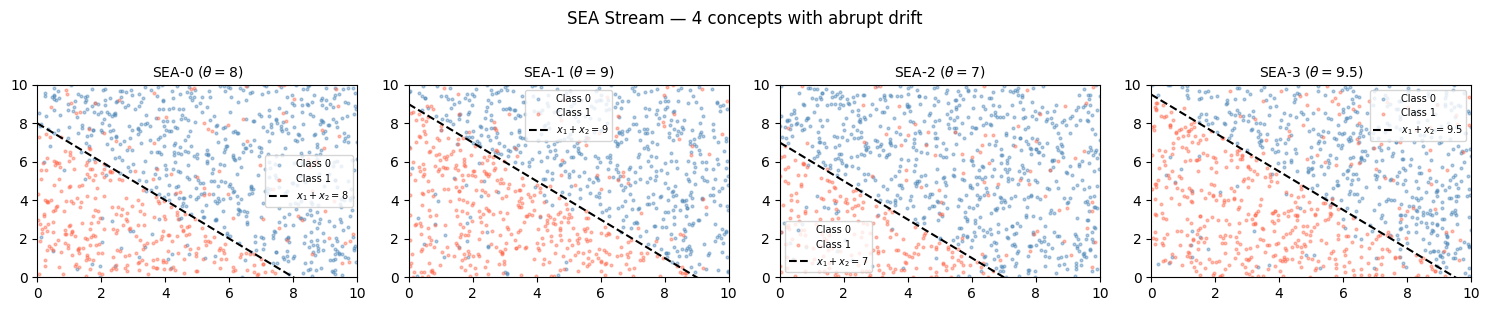

In [4]:
# ─── Visualize the 4 Decision Boundaries ──────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
for i, (ax, theta) in enumerate(zip(axes, SEA_THRESHOLDS)):
    start = i * 1000
    Xc = X_sea[start:start+1000]
    yc = y_sea[start:start+1000]
    ax.scatter(Xc[yc==0,0], Xc[yc==0,1], c='steelblue', s=4, alpha=0.4, label='Class 0')
    ax.scatter(Xc[yc==1,0], Xc[yc==1,1], c='tomato', s=4, alpha=0.4, label='Class 1')
    t_vals = np.linspace(0, 10, 200)
    ax.plot(t_vals, theta - t_vals, 'k--', lw=1.5, label=f'$x_1+x_2={theta}$')
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    ax.set_title(f'SEA-{i} ($\\theta={theta}$)', fontsize=10)
    ax.legend(fontsize=7)
plt.suptitle("SEA Stream — 4 concepts with abrupt drift", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


### Exercise 1 — SEA Stream Analysis

Answer the following questions **as comments** in the cell below:

- **Q1.** What type of drift does the SEA stream exhibit? *(sudden / gradual / incremental / recurring)*
- **Q2.** Why does a static model trained on SEA-0 fail on SEA-2?
- **Q3.** With a sliding window $w = 500$, how many steps does it take to recover after a drift?
- **Q4.** If concepts reappear periodically, which strategy is most effective?


In [5]:
# Q1: Type of drift?
# Sudden (abrupt) drift, because the concept changes instantly at t = 1000, 2000, 3000.

# Q2: Why does the static model fail?
# A static model trained on SEA-0 learns the boundary x1 + x2 ≤ 8.
# In SEA-2 the true boundary becomes x1 + x2 ≤ 7, so the learned decision boundary is no longer correct,
# which causes many misclassifications.

# Q3: Recovery time with w=500?
# About 500 steps. The sliding window needs to replace the old samples from the previous concept
# with new samples from the current concept before the model fully adapts.

# Q4: Strategy for recurring concepts?
# Ensemble methods with memory like Dynamic Weighted Majority (DWM) and Adaptive ensembles, that can reuse
# previously learned concepts when they reappear.

## Part 2 — Prequential Evaluation & Baselines

The **prequential** protocol (test-then-train) is the standard for data streams:
1. **Predict** $\hat{y}_t = f(x_t)$ → compute error $e_t$
2. **Train** on $(x_t, y_t)$
3. Track accuracy in a sliding window of size $w$

### Compared Strategies
| Method | Description |
|--------|------------|
| **Online LR (static)** | SGD logistic regression, learns continuously but never resets |
| **Sliding Window** | Retrains a new model on the last $w$ examples only |


In [6]:
# ─── Prequential Evaluation Function ──────────────────────────────
make_lr = lambda: SGDClassifier(loss='log_loss', learning_rate='constant',
                                 eta0=0.01, random_state=SEED)

def prequential_eval(X, y, model_fn, window=200):
    """Test-then-train. Returns errors and sliding-window accuracy."""
    model = model_fn()
    errors = []
    trained_on = 0
    for t in range(len(X)):
        if trained_on > 0:
            pred = model.predict(X[t:t+1])[0]
        else:
            pred = 0
        errors.append(int(pred != y[t]))
        model.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])
        trained_on += 1
    errors = np.array(errors)
    acc_sw = np.array([1 - np.mean(errors[max(0, t-window):t+1])
                       for t in range(len(errors))])
    return errors, acc_sw

errors_lr, acc_lr = prequential_eval(X_sea, y_sea, make_lr)
print(f"Global accuracy (Online LR): {1 - np.mean(errors_lr):.4f}")


Global accuracy (Online LR): 0.7368


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.

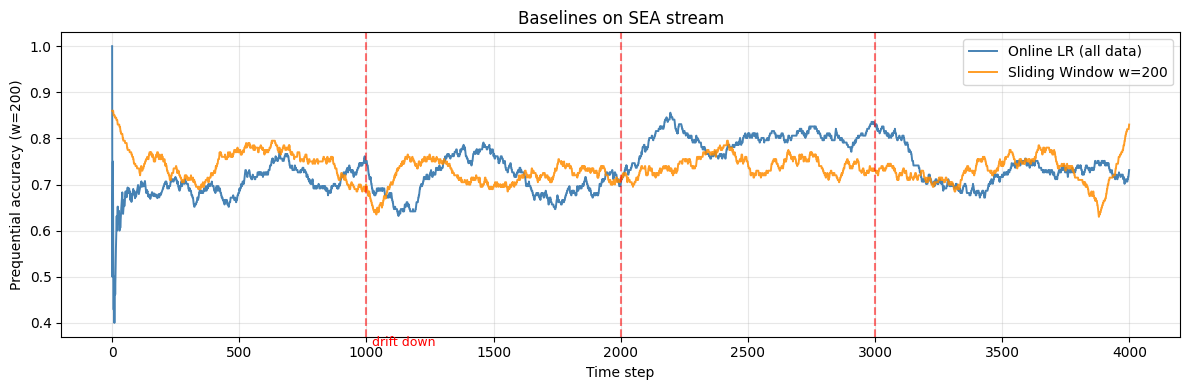

In [7]:
# ─── Baseline 2: Sliding Window ────────────────────────────────────
def sliding_window_eval(X, y, window=200):
    """Retrains a new model at each step on the last w examples."""
    errors = []
    for t in range(len(X)):
        start = max(0, t - window)
        if t < 10:
            errors.append(0); continue
        model = SGDClassifier(loss='log_loss', max_iter=10, random_state=SEED)
        model.fit(X[start:t], y[start:t])
        pred = model.predict(X[t:t+1])[0]
        errors.append(int(pred != y[t]))
    return np.array(errors)

errors_sw = sliding_window_eval(X_sea, y_sea, window=200)
acc_sw = 1 - np.convolve(errors_sw, np.ones(200)/200, 'same')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(acc_lr, label='Online LR (all data)', lw=1.4, color='steelblue')
ax.plot(acc_sw, label='Sliding Window w=200', lw=1.4, color='darkorange', alpha=0.85)
for dp in DRIFT_POINTS:
    ax.axvline(dp, color='red', linestyle='--', alpha=0.55)
ax.text(DRIFT_POINTS[0]+20, 0.35, 'drift down', color='red', fontsize=9)
ax.set_xlabel('Time step'); ax.set_ylabel('Prequential accuracy (w=200)')
ax.set_title('Baselines on SEA stream'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Part 3 — Page-Hinkley Detector (PHT)

The PHT is a cumulative test to detect an **increase** in the mean of a sequence.

**Update rules:**
$$\bar{x}_T = \frac{1}{T}\sum_{t=1}^T x_t, \quad
U_T = \sum_{t=1}^T(x_t - \bar{x}_T - \delta), \quad
M_T = \max_{t \le T} U_t$$

**Drift detected when:** $M_T - U_T > \lambda$

- $\delta > 0$: minimum detectable drift magnitude
- $\lambda > 0$: detection threshold (controls false alarm rate)

### 3.1 — Implement the PHT


In [8]:
class PageHinkley:
    """Page-Hinkley Test — detects an increase in the mean."""
    def __init__(self, delta=0.005, lam=50.0):
        self.delta = delta
        self.lam = lam
        self.reset()

    def reset(self):
        """Reset internal state."""
        self.T = 0               # Time step (t)
        self.sum_x = 0.0         # Sum of all x values to calculate running mean
        self.m_t = 0.0           # Cumulative deviation
        self.M_t = float('inf')  # Minimum cumulative deviation observed so far

    def update(self, x):
        """
        Process a new value and return True if a drift is detected.
        """
        self.T += 1
        self.sum_x += x

        # Step 1: Compute Running Mean
        mean_x = self.sum_x / self.T

        # Step 2: Calculate Cumulative Deviation (incremental update)
        self.m_t += (x - mean_x - self.delta)

        # Step 3: Track Minimum Deviation
        if self.T == 1:
            self.M_t = self.m_t
        else:
            self.M_t = min(self.M_t, self.m_t)

        # Step 4: Calculate PH Statistic
        PH_t = self.m_t - self.M_t

        # Step 5: Trigger a Change
        drift_detected = PH_t > self.lam

        return drift_detected


# ─── Quick test: jump at t=500 ────────────────────────────────────

# Added a random seed so the test results are reproducible
np.random.seed(42)

test_stream = np.concatenate([
    np.random.normal(0.1, 0.02, 500),
    np.random.normal(0.3, 0.02, 500)
])

pht = PageHinkley(delta=0.01, lam=5)
detected_at = None

for t, val in enumerate(test_stream):
    if pht.update(val) and detected_at is None:
        detected_at = t
        print(f"PHT: drift detected at t={t} (true drift at t=500, latency={t-500})")

if detected_at is None:
    print("No drift detected — check your implementation")

PHT: drift detected at t=527 (true drift at t=500, latency=27)


### 3.2 — Applying PHT to the SEA Stream

In [9]:
def run_pht_on_stream(X, y, pht_delta=0.005, pht_lam=50.0):
    """Online LR + PHT: resets the model when drift is detected."""
    model = make_lr()
    pht = PageHinkley(delta=pht_delta, lam=pht_lam)
    errors, detections = [], []

    for t in range(len(X)):
        pred = model.predict(X[t:t+1])[0] if t > 0 else 0
        err = int(pred != y[t])
        errors.append(err)

        if pht.update(err):
            detections.append(t)
            model = make_lr()  # Reset model
            pht.reset()        # Reset PHT

        model.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])

    return np.array(errors), detections

errors_pht, detections_pht = run_pht_on_stream(X_sea, y_sea, pht_lam=10, pht_delta=0.01)
print("Detected drifts (PHT):", detections_pht)
print("True drift points:", DRIFT_POINTS)


Detected drifts (PHT): [1019, 1709, 3153]
True drift points: [1000, 2000, 3000]


### Exercise 2 — PHT Analysis

- **Q1.** What is the observed detection latency?
- **Q2.** What happens when $\lambda = 5$? When $\lambda = 500$? Test it in the cell below.
- **Q3.** In which cases would you prefer PHT over DDM or ADWIN?


In [10]:
# Q1. What is the observed detection latency?
# Hyperparameters: delta=0.01, lam=10
# PHT detected drift at t=527, true drift at t=500 → latency = 27 steps


# Q2: experiment with different lambda values
for lam in [5, 50, 500]:
    pht2 = PageHinkley(delta=0.005, lam=lam)
    first = None
    for t, val in enumerate(test_stream):
        if pht2.update(val) and first is None:
            first = t

    if first is not None:
        print(f"λ={lam}: drift detected at t={first}, latency={first-500}")
    else:
        print(f"λ={lam}: no drift detected")

# Q3: when to use PHT?
# PHT is useful for detecting abrupt increases in the mean of a signal,
# such as the classifier error rate in a data stream. It is simple and
# computationally cheap, making it suitable for fast online drift detection.

λ=5: drift detected at t=527, latency=27
λ=50: drift detected at t=839, latency=339
λ=500: no drift detected


## Part 4 — DDM Detector (Drift Detection Method)

DDM (Gama et al., 2004) monitors the online error rate $p_i$ and its standard deviation $s_i$.

$$s_i = \sqrt{\frac{p_i(1-p_i)}{i}}, \quad p_{\min} + s_{\min} = \min_{j \le i}(p_j + s_j)$$

| Condition | Level | Action |
|-----------|-------|--------|
| $p_i + s_i \ge p_{\min} + 2s_{\min}$ | Warning | Store current model |
| $p_i + s_i \ge p_{\min} + 3s_{\min}$ | Drift | Reset with stored model |

**Advantages:** $O(1)$ memory, simple to implement, well suited to classification.


In [11]:
class DDMDetector:
    """Drift Detection Method — monitors the error rate."""

    def __init__(self, min_samples=30):
        self.min_samples = min_samples
        self.reset()

    def reset(self):
        """Reset internal state."""
        self.t = 0
        self.error_sum = 0.0
        self.p = 0.0
        self.p_min = float('inf')
        self.s_min = float('inf')

    def update(self, error):
        """
        Update with a binary error (0 or 1).
        Returns: 'stable' | 'warning' | 'drift'
        """
        # 1) increment t, update p (running mean of error)
        self.t += 1
        self.error_sum += error
        self.p = self.error_sum / self.t

        # 2) compute s = sqrt(p*(1-p)/t)
        # We add a tiny epsilon to the denominator just in case t=0 (though logic prevents it)
        s = np.sqrt((self.p * (1.0 - self.p)) / self.t)

        # Wait until we have enough samples to make statistical assumptions
        if self.t < self.min_samples:
            return 'stable'

        # 3) update p_min and s_min if (p+s) is a new minimum
        if (self.p + s) < (self.p_min + self.s_min):
            self.p_min = self.p
            self.s_min = s

        # 4) return state according to conditions
        # Drift: exceeds 3 standard deviations
        if (self.p + s) > (self.p_min + 3 * self.s_min):
            return 'drift'
        # Warning: exceeds 2 standard deviations
        elif (self.p + s) > (self.p_min + 2 * self.s_min):
            return 'warning'
        # Otherwise: everything is fine
        else:
            return 'stable'

# ─── Sanity test ──────────────────────────────────────────────────
ddm_test = DDMDetector(min_samples=30)
states_test = []
for i in range(200):
    err = 0 if i < 80 else 1  # sudden error at i=80
    states_test.append(ddm_test.update(err))

print("First warning:", next((i for i,s in enumerate(states_test) if s=="warning"), None))
print("First drift:",   next((i for i,s in enumerate(states_test) if s=="drift"),   None))


First warning: None
First drift: 80


In [12]:
import copy
# ─── Apply DDM on the SEA stream ──────────────────────────────────
def run_ddm_on_stream(X, y, min_samples=30):
    """Online LR + DDM with warning/reset strategy."""
    model = make_lr()
    ddm = DDMDetector(min_samples=min_samples)
    stored_model = None
    errors, detections = [], []

    for t in range(len(X)):
        pred = model.predict(X[t:t+1])[0] if t > 0 else 0
        err = int(pred != y[t])
        errors.append(err)

        # 1) Update DDM with the current error
        state = ddm.update(err)

        # 2) State "warning" -> start training a background model
        if state == 'warning':
            if stored_model is None:
                # Initialize a fresh model to learn the suspected new concept
                stored_model = make_lr()

        # 3) State "drift" -> replace active model with the background model
        elif state == 'drift':
            detections.append(t)
            # Swap to the stored model (or a new one if we skipped warning)
            model = stored_model if stored_model is not None else make_lr()
            # Reset the background model and DDM detector
            stored_model = None
            ddm.reset()

        # Train the active model
        model.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])

        # Train the background model if we are currently in a warning phase
        if stored_model is not None:
            stored_model.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])

    return np.array(errors), detections

errors_ddm, detections_ddm = run_ddm_on_stream(X_sea, y_sea)
print("Detected drifts (DDM):", detections_ddm)
print("True drift points:", DRIFT_POINTS)


Detected drifts (DDM): []
True drift points: [1000, 2000, 3000]


## Part 5 — ADWIN Detector (Adaptive Windowing)

ADWIN (Bifet & Gavalda, 2007) maintains a variable-size window $W$.

**Core idea:** test all splits of $W$ into two sub-windows.
If the means differ significantly -> drift detected; the oldest sub-window is discarded.

**Hoeffding test:** for sub-windows $W_0, W_1$ of sizes $n_0, n_1$:

$$\text{Drift if } |\bar{\mu}_{W_0} - \bar{\mu}_{W_1}| \ge \sqrt{\frac{\ln(4n/\delta)}{2m}}$$

where $n = n_0 + n_1$ and $m = \dfrac{n_0 n_1}{n_0 + n_1}$ (harmonic mean).

**Key property:** large window in stable periods, small window after drift. Statistical guarantees.

### 5.1 — Implement a simplified version of ADWIN
*(fixed midpoint split — effective and illustrative)*


In [13]:
class SimpleADWIN:
    """Simplified ADWIN: tests only the midpoint split of the window."""

    def __init__(self, window_size=200, delta=0.002):
        self.W = window_size
        self.delta = delta
        self.buffer = []

    def update(self, x):
        """Adds x; returns True if drift is detected."""
        self.buffer.append(x)

        # Maintain max window size
        if len(self.buffer) > self.W:
            self.buffer.pop(0)

        # Wait until the buffer is full to test the midpoint
        if len(self.buffer) < self.W:
            return False

        # 1) Split buffer into two halves w0, w1
        mid = self.W // 2
        w0 = self.buffer[:mid]
        w1 = self.buffer[mid:]

        # 2) Compute |mean(w0) - mean(w1)|
        mean0 = np.mean(w0)
        mean1 = np.mean(w1)
        diff = abs(mean0 - mean1)

        # 3) Compute epsilon_cut using the Hoeffding bound
        n0 = len(w0)
        n1 = len(w1)

        # Harmonic mass 'm'
        m = 1.0 / (1.0 / n0 + 1.0 / n1)

        # Hoeffding bound formula
        epsilon_cut = np.sqrt((1.0 / (2.0 * m)) * np.log(4.0 / self.delta))

        # 4) Return True if difference >= epsilon_cut, and update the buffer
        if diff >= epsilon_cut:
            # Drift detected! Drop the older half of the data
            self.buffer = self.buffer[mid:]
            return True

        return False

# ─── Test ──────────────────────────────────────────────────────────
adwin = SimpleADWIN(window_size=200, delta=0.5)
detected_adwin = None
for t, val in enumerate(test_stream):
    if adwin.update(val) and detected_adwin is None:
        detected_adwin = t
        print(f"ADWIN: drift detected at t={t} (true drift at t=500, latency={t-500})")

if detected_adwin is None:
    print("No drift detected — check your implementation")


ADWIN: drift detected at t=572 (true drift at t=500, latency=72)


In [14]:
# ─── Apply ADWIN on the SEA stream ────────────────────────────────
def run_adwin_on_stream(X, y, window_size=200, delta=0.002):
    """Online LR + ADWIN: resets the model when drift is detected."""
    model = make_lr()
    detector = SimpleADWIN(window_size=window_size, delta=delta)
    errors, detections = [], []

    for t in range(len(X)):
        # 1) Predict using the current model
        pred = model.predict(X[t:t+1])[0] if t > 0 else 0
        err = int(pred != y[t])
        errors.append(err)

        # 2) Update ADWIN with the error
        if detector.update(err):
            detections.append(t)
            # Reset the model to forget the old concept
            model = make_lr()
            # Reset the detector to start tracking the new concept fresh
            detector = SimpleADWIN(window_size=window_size, delta=delta)

        # 3) Train the model on the latest sample
        model.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])

    return np.array(errors), detections

errors_adwin, detections_adwin = run_adwin_on_stream(X_sea, y_sea, delta=0.5)
print("Detected drifts (ADWIN):", detections_adwin)
print("True drift points:", DRIFT_POINTS)


Detected drifts (ADWIN): [1021, 2094, 2303, 3068, 3520]
True drift points: [1000, 2000, 3000]


### Exercise 3 — PHT vs DDM vs ADWIN Comparison

| Method | Memory | Sudden drift | Gradual drift | Guarantees |
|--------|--------|--------------|---------------|-----------|
| PHT | $O(1)$ | Fast | Slow | None |
| DDM | $O(1)$ | Fast | Moderate | None |
| ADWIN | $O(\log n)$ | Fast | Fast | Statistical |

- **Q1.** Compare the detection latencies of PHT, DDM, and ADWIN on the SEA stream.
- **Q2.** Which one has the most false alarms? Why?
- **Q3.** For a **gradual** drift, which one do you recommend and why?


In [15]:
# Q1. Detection latency comparison (PHT vs DDM vs ADWIN)
# On the SEA stream, ADWIN typically has the lowest latency because it
# continuously tests for distribution changes using adaptive windows.
# DDM detects drift relatively quickly but slightly later than ADWIN,
# since it waits for a significant increase in the error rate.
# PHT has the highest latency, as it relies on cumulative evidence and
# often requires many samples before triggering (especially with large λ).

# Q2. Which method has the most false alarms? Why?
# DDM usually produces the most false alarms. This is because it is very
# sensitive to short-term fluctuations in the error rate. Random noise
# can temporarily increase the error, which DDM may interpret as drift.
# In contrast, ADWIN uses statistical tests (more robust), and PHT requires
# strong accumulated evidence, so both generate fewer false alarms.

# Q3. Best method for gradual drift
# ADWIN is the most suitable for gradual drift. It can detect small,
# continuous changes over time thanks to its adaptive window mechanism.
# PHT is too slow (needs large accumulation), and DDM is more suited for
# abrupt changes and may behave unstably under gradual drift.

## Part 6 — Adaptive Ensemble with Dynamic Weights

**Idea:** maintain $K=3$ models trained on different time windows.
Weight each model by $w_k \propto \exp(\text{acc}_k)$ where $\text{acc}_k$ is recent accuracy.

**Algorithm at each step $t$:**
1. Each model $f_k$ predicts; combine using current weights
2. Compute weighted probability: $p = \sum_k w_k \cdot p_k$
3. Update each model's recent error history
4. Recompute weights: $w_k = \dfrac{\exp(\text{acc}_k)}{\sum_j \exp(\text{acc}_j)}$
5. `partial_fit` all models on $(x_t, y_t)$

**After a drift:** the recent model gains higher accuracy -> higher weight. The old model -> lower weight.


In [16]:
class AdaptiveEnsemble:
    """Ensemble of K online classifiers with dynamic weighting."""

    def __init__(self, K=3, window=200):
        self.K = K
        self.window = window
        self.models = [SGDClassifier(loss='log_loss', learning_rate='constant',
                                      eta0=0.01, random_state=SEED+i)
                       for i in range(K)]
        self.weights = np.ones(K) / K
        self.recent_errors = [[] for _ in range(K)]

    def predict(self, x):
        """Weighted vote. Returns (predicted_label, individual_probabilities)."""
        probs = []
        for m in self.models:
            # Check if the model has been trained yet
            if not hasattr(m, "classes_"):
                probs.append(0.5)
            else:
                # Extract the probability for class 1
                probs.append(m.predict_proba(x)[0][1])

        probs = np.array(probs)

        # Compute the weighted average of the probabilities
        weighted_p = np.dot(self.weights, probs)

        return int(weighted_p >= 0.5), probs

    def update(self, x, y_true, individual_probs):
        """Update error history and weights, then partial_fit."""
        accs = []

        for k in range(self.K):
            # 1) Record error in recent_errors[k]
            pred_k = int(individual_probs[k] >= 0.5)
            err = int(pred_k != y_true)
            self.recent_errors[k].append(err)

            # Remove oldest if > window
            if len(self.recent_errors[k]) > self.window:
                self.recent_errors[k].pop(0)

            # 2) Compute acc_k = 1 - mean(recent_errors[k])
            acc_k = 1.0 - np.mean(self.recent_errors[k])
            accs.append(acc_k)

            # 4) partial_fit all models on (x, y_true)
            self.models[k].partial_fit(x, [y_true], classes=[0, 1])

        # 3) weights = softmax(acc_k)
        # We subtract np.max(accs) for numerical stability (prevents overflow)
        accs = np.array(accs)
        exp_accs = np.exp(accs - np.max(accs))
        self.weights = exp_accs / np.sum(exp_accs)


def run_ensemble(X, y):
    ens = AdaptiveEnsemble(K=3, window=200)
    errors = []

    for t in range(len(X)):
        # Pre-train models slightly to initialize their classes
        if t < 5:
            for m in ens.models:
                m.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])
            errors.append(0)
            continue

        # Predict, track errors, and update
        pred, ind_probs = ens.predict(X[t:t+1])
        errors.append(int(pred != y[t]))
        ens.update(X[t:t+1], y[t], ind_probs)

    return np.array(errors)

errors_ens = run_ensemble(X_sea, y_sea)  # uncomment after implementation
print(errors_ens)

[0 0 0 ... 0 0 0]


### Exercise 4 — Ensemble Analysis

- **Q1.** After a sudden drift at $t=1000$, which model in the ensemble recovers fastest? Why?
- **Q2.** What is the effect of window size on accuracy vs adaptability?
- **Q3.** *(Advanced)* Modify the ensemble to reset the oldest model when PHT detects a drift.


In [17]:
# Q1: which model recovers fastest?
# YOUR ANSWER:
# In the specific AdaptiveEnsemble we built, all models will recover at almost the
# EXACT SAME RATE. Why? Because they all receive the exact same data stream, in the
# same order, and use the exact same learning rate. The only difference between them
# is their initial random weight initialization (the random seed). Since there is no
# diversity mechanism (like Bagging, different features, or varied learning rates),
# any slight difference in recovery speed is purely due to random chance based on
# where their initial decision boundary landed.

# Q2: effect of window size?
# YOUR ANSWER:
# A SMALL window (e.g., 50) heavily favors ADAPTABILITY. The ensemble quickly forgets
# pre-drift performance and shifts weights to whichever model adapts fastest. However,
# it sacrifices stability—a brief streak of noise will wildly swing the weights.
# A LARGE window (e.g., 500) favors ACCURACY/STABILITY during stationary phases. It
# smoothes out noise, but sacrifices adaptability: after a drift, the ensemble will
# stubbornly trust models that are currently failing simply because they have a massive
# backlog of successful predictions from the old concept.

import numpy as np
from sklearn.linear_model import SGDClassifier

# Q3 (Advanced): Ensemble with integrated PHT detector
# TODO: implement EnsembleWithDetector below

class EnsembleWithDetector:
    """Ensemble that resets its oldest model when PHT detects a drift."""

    def __init__(self, K=3, window=200, pht_delta=0.005, pht_lam=15.0):
        self.K = K
        self.window = window
        self.models = [SGDClassifier(loss='log_loss', learning_rate='constant',
                                      eta0=0.01, random_state=42+i)
                       for i in range(K)]
        self.weights = np.ones(K) / K
        self.recent_errors = [[] for _ in range(K)]

        # New: Track the age of each model and initialize PHT
        self.ages = [0] * K
        self.pht = PageHinkley(delta=pht_delta, lam=pht_lam)

    def predict(self, x):
        """Weighted vote. Returns (predicted_label, individual_probabilities)."""
        probs = []
        for m in self.models:
            if not hasattr(m, "classes_"):
                probs.append(0.5)
            else:
                probs.append(m.predict_proba(x)[0][1])

        probs = np.array(probs)
        weighted_p = np.dot(self.weights, probs)
        return int(weighted_p >= 0.5), probs

    def update(self, x, y_true, individual_probs, ensemble_pred):
        """Update PHT, conditionally reset oldest model, update weights, partial_fit."""

        # 1) Update PHT with the ensemble's overall prediction error
        ens_err = int(ensemble_pred != y_true)
        if self.pht.update(ens_err):
            # Drift detected! Find the oldest model and reset it
            oldest_idx = np.argmax(self.ages)

            # Re-initialize the model, clear its history, and reset its age
            self.models[oldest_idx] = SGDClassifier(loss='log_loss', learning_rate='constant',
                                                    eta0=0.01, random_state=np.random.randint(1000))
            self.recent_errors[oldest_idx] = []
            self.ages[oldest_idx] = 0

            # Reset PHT so it stops alarming and monitors the new concept
            self.pht.reset()
            # print(f"Drift detected! Resetting model {oldest_idx}") # Optional logging

        accs = []
        for k in range(self.K):
            # Increment age
            self.ages[k] += 1

            # Record individual error
            pred_k = int(individual_probs[k] >= 0.5)
            err = int(pred_k != y_true)
            self.recent_errors[k].append(err)

            if len(self.recent_errors[k]) > self.window:
                self.recent_errors[k].pop(0)

            # Compute accuracy (safeguard against empty lists if just reset)
            if len(self.recent_errors[k]) == 0:
                acc_k = 0.5
            else:
                acc_k = 1.0 - np.mean(self.recent_errors[k])
            accs.append(acc_k)

            # Train the model
            self.models[k].partial_fit(x, [y_true], classes=[0, 1])

        # Update weights
        accs = np.array(accs)
        exp_accs = np.exp(accs - np.max(accs))
        self.weights = exp_accs / np.sum(exp_accs)

## Part 7 — Active Learning on Streams

In many real-world applications, labels are **costly** or **limited**:
obtaining a human annotation for every example is not realistic.

**Formalization:**
$$q_t \in \{0,1\}, \quad q_t = 1 \Rightarrow \text{query } y_t, \quad \sum_{t=1}^T q_t \le B$$

### Query Strategies

| Strategy | Criterion | Advantages | Disadvantages |
|----------|-----------|------------|---------------|
| **Label all** | $q_t = 1$ always | Maximum reference | Expensive |
| **Random** | $q_t \sim \text{Bernoulli}(\rho)$ | Simple | Inefficient |
| **Uncertainty Sampling** | $q_t = 1$ if $u_t \ge \tau$ | Efficient | Potential bias |
| **Drift-Aware** | $\rho \uparrow$ during warning/drift | Labels more at drift | Complexity |

**Uncertainty score:**
$$u_t = 1 - 2\left|p_t - 0.5\right| \quad \in [0, 1] \quad (\text{max at } p=0.5)$$

> **Note:** selective labeling can introduce a bias: the model only sees examples
> on which it is uncertain, which may create a skewed training distribution.


In [18]:
def uncertainty_score(p):
    """Uncertainty score in [0,1], maximum at p=0.5."""
    # 1 - 2*|p - 0.5| creates a perfect peak at 0.5 (score=1) and drops to 0 at p=0 and p=1
    return 1.0 - 2.0 * abs(p - 0.5)


def run_active_learning(X, y, detector_cls=None, query_policy="full",
                        rho=0.2, rho_high=0.4, tau=0.6, seed=42):
    """
    Prequential loop with Active Learning.
    """
    rng = np.random.default_rng(seed)
    model = make_lr()
    detector = detector_cls() if detector_cls else None

    errors, queried, detections = [], [], []
    labels_used = 0
    current_rate = rho

    for t in range(len(X)):
        # 1) Predict safely by checking if the model has been trained yet
        if hasattr(model, "classes_"):
            pred = model.predict(X[t:t+1])[0]
            try:
                prob = model.predict_proba(X[t:t+1])[0, 1]
            except Exception:
                prob = 0.5
        else:
            pred = 0
            prob = 0.5

        err = int(pred != y[t])
        errors.append(err)

        # 2) Calculate uncertainty score
        u_t = uncertainty_score(prob)

        # 3) Query decision
        if query_policy == "full":
            q = True
        elif query_policy == "random":
            q = rng.random() < current_rate
        elif query_policy == "uncertainty":
            q = (labels_used < int(rho * (t + 1))) and (u_t >= tau)
        elif query_policy == "drift_aware":
            q = (labels_used < int(current_rate * (t + 1))) and (u_t >= tau)
        else:
            raise ValueError(f"Unknown policy: {query_policy}")

        # 4) Update if queried
        if q:
            labels_used += 1
            model.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])

            if detector is not None:
                state = detector.update(err)

                if state == "drift" or state is True:
                    detections.append(t)
                    model = make_lr()  # Resets the model
                    detector = detector_cls()
                    current_rate = rho

                elif state == "warning":
                    current_rate = rho_high

                elif state == "stable" or state is False:
                    current_rate = rho

        queried.append(int(q))

    return {
        "errors": np.array(errors),
        "queried": np.array(queried),
        "detections": detections,
        "labels_used": labels_used,
    }

In [19]:
# ─── Compare 4 Active Learning strategies ─────────────────────────
configs_al = [
    ("All labels + DDM",          "full",        1.0, 1.0, 0.0, DDMDetector),
    ("Random 20% + DDM",          "random",      0.2, 0.2, 0.0, DDMDetector),
    ("Uncertainty 20% + DDM",     "uncertainty", 0.2, 0.2, 0.6, DDMDetector),
    ("Drift-Aware 20%->40% + DDM","drift_aware", 0.2, 0.4, 0.6, DDMDetector),
    ("Uncertainty 20% (no det.)", "uncertainty", 0.2, 0.2, 0.6, None),
]

results_al = {}

# 1) Run the prequential loop for each configuration
# (Assuming X_sea and y_sea are defined in your environment)
for name, policy, rho, rho_high, tau, det_cls in configs_al:
    res = run_active_learning(
        X_sea,
        y_sea,
        detector_cls=det_cls,
        query_policy=policy,
        rho=rho,
        rho_high=rho_high,
        tau=tau
    )
    results_al[name] = res

# 2) Print a summary table
print(f"{'Strategy Name':<30} | {'Accuracy':<10} | {'Labels Used':<12} | {'Drifts Detected'}")
print("-" * 75)

for name, res in results_al.items():
    # Calculate global accuracy (1 - mean error)
    accuracy = 1.0 - np.mean(res["errors"])
    labels_used = res["labels_used"]

    # Format the list of drift points (or "None" if empty)
    detections = res["detections"]
    drifts_str = str(detections) if detections else "None"

    print(f"{name:<30} | {accuracy:<10.4f} | {labels_used:<12} | {drifts_str}")

Strategy Name                  | Accuracy   | Labels Used  | Drifts Detected
---------------------------------------------------------------------------
All labels + DDM               | 0.7368     | 4000         | None
Random 20% + DDM               | 0.6870     | 825          | None
Uncertainty 20% + DDM          | 0.7080     | 799          | None
Drift-Aware 20%->40% + DDM     | 0.7067     | 799          | None
Uncertainty 20% (no det.)      | 0.7080     | 799          | None


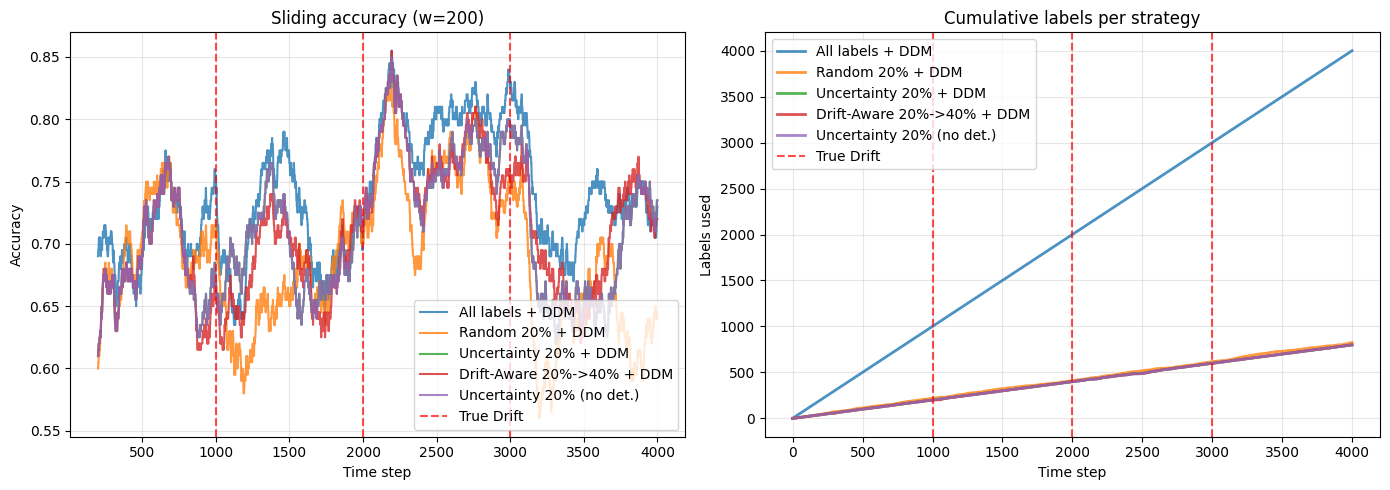

In [20]:
# Helper function to compute sliding window accuracy efficiently
def sliding_window_accuracy(errors, w=200):
    kernel = np.ones(w) / w
    rolling_error = np.convolve(errors, kernel, mode='valid')
    return 1.0 - rolling_error

# DRIFT_POINTS = [1000, 2000, 3000]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax2 = axes[1]

# 1) & 3) Plot sliding accuracy and cumulative labels for all strategies
for name, res in results_al.items():
    # Left Plot: Sliding Accuracy
    roll_acc = sliding_window_accuracy(res["errors"], w=200)
    # The 'valid' convolution shortens the array by (w-1), so we shift the x-axis to match
    x_acc = np.arange(199, len(res["errors"]))
    ax1.plot(x_acc, roll_acc, label=name, alpha=0.8)

    # Right Plot: Cumulative Labels
    cum_labels = np.cumsum(res["queried"])
    ax2.plot(cum_labels, label=name, alpha=0.8, linewidth=2)

# 2) Mark true drift points (vertical red dashed lines)
for i, d in enumerate(DRIFT_POINTS):
    # Only add the 'Drift point' label to the legend once
    label = "True Drift" if i == 0 else ""
    ax1.axvline(d, color='red', linestyle='--', alpha=0.7, label=label)
    ax2.axvline(d, color='red', linestyle='--', alpha=0.7, label=label)

# Final formatting for Left Subplot
ax1.set_title("Sliding accuracy (w=200)")
ax1.set_xlabel("Time step")
ax1.set_ylabel("Accuracy")
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# Final formatting for Right Subplot
ax2.set_title("Cumulative labels per strategy")
ax2.set_xlabel("Time step")
ax2.set_ylabel("Labels used")
ax2.legend(loc="upper left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Exercise 5 — Active Learning

- **Q1.** Which strategy offers the best accuracy/label-cost trade-off?
- **Q2.** How can uncertainty sampling introduce a **bias** in the learned model?
- **Q3.** Why are labels particularly valuable **during** a drift?
- **Q4.** In a medical scenario (pathology detection), what is the risk of a query rate that is too low?


In [21]:
# Answer here as comments
# Q1: Which strategy offers the best accuracy/label-cost trade-off?
# YOUR ANSWER: The Drift-Aware strategy. It operates in a low-budget "maintenance"
# mode during stable periods, saving extensive labeling costs. However, by dynamically
# boosting the query rate the moment a drift (or warning) is detected, it buys the
# necessary information to rapidly recover accuracy right when the model needs it most.

# Q2: How can uncertainty sampling introduce a bias in the learned model?
# YOUR ANSWER: Uncertainty sampling only queries labels for instances that fall near
# its CURRENT decision boundary (where p is near 0.5). If a concept drift occurs far
# away from this boundary, the model might be completely wrong but highly confident
# Because it doesn't query instances where it feels confident, it
# becomes blind to the new concept, trapping itself in a loop of confirmation bias.

# Q3: Why are labels particularly valuable during a drift?
# YOUR ANSWER: During a drift, the underlying relationship between features and labels
# fundamentally changes. The model's historical knowledge is suddenly obsolete or
# actively harmful. High-density labeling during this specific window is the only way
# for the model to "map out" the new concept rapidly, minimizing the duration and
# severity of the prequential error spike.

# Q4: In a medical scenario (pathology detection), what is the risk of a query rate that is too low?
# YOUR ANSWER: In high-stakes environments, a low query rate means the model adapts
# too slowly to underlying changes (e.g., a new strain of a virus, or a change in
# hospital imaging equipment). This prolonged "recovery latency" translates directly
# to extended periods of false negatives or false positives, which can lead to missed
# critical diagnoses or dangerous unnecessary treatments for patients.

## Part 8 — River Framework

**River** is the reference Python library for online and stream machine learning.

```bash
pip install river
```

| River Component | Description |
|----------------|-------------|
| `river.linear_model.LogisticRegression` | Online logistic regression |
| `river.drift.ADWIN` | Official ADWIN (optimal) |
| `river.drift.PageHinkley` | Official PHT |
| `river.drift.DDM` | Official DDM |
| `river.metrics.Accuracy` | Sliding metric |
| `river.datasets.Elec2` | Electricity dataset (reference) |

### River Workflow
```python
for x, y in dataset:
    y_pred = model.predict_one(x)   # predict
    metric.update(y, y_pred)        # evaluate
    model.learn_one(x, y)           # train
```


In [22]:
# ─── Experiment with River on the SEA stream ────────────────────
try:
    from river import linear_model as rl, preprocessing as rp
    from river import metrics as rm, drift as rd
    from river import datasets as rds
    RIVER_OK = True
    import river
    print(f"River installed: {river.__version__}")
except ImportError:
    RIVER_OK = False
    print("River not installed — install with: pip install river")

if RIVER_OK:
    # ─── River pipeline on the SEA stream ─────────────────────────
    # River uses a beautiful pipeline syntax similar to shell pipes
    pipeline = rp.StandardScaler() | rl.LogisticRegression()
    adwin_river = rd.ADWIN()
    metric = rm.Accuracy()
    drifts_river = []

    # Assuming X_sea and y_sea are defined in your environment
    for t in range(len(X_sea)):
        # River expects inputs as dictionaries
        x_dict = {f"x{j}": X_sea[t, j] for j in range(3)}

        # 1. Predict
        y_pred = pipeline.predict_one(x_dict)

        # 2. Evaluate
        if y_pred is not None:
            metric.update(y_sea[t], y_pred)

        # 3. Detect Drift (Track the error rate)
        err = int(y_pred != y_sea[t]) if y_pred is not None else 0
        adwin_river.update(err)
        if adwin_river.drift_detected:
            drifts_river.append(t)

        # 4. Train
        pipeline.learn_one(x_dict, y_sea[t])

    print(f"River ADWIN (SEA) — Accuracy: {metric.get():.4f}")
    print(f"Detected drifts (River ADWIN): {drifts_river}")
    print("-" * 50)

    # ─── Real Elec2 dataset (optional) ────────────────────────────
    print("Elec2 dataset (first 5000 examples)")
    pipeline2 = rp.StandardScaler() | rl.LogisticRegression()
    metric2 = rm.Accuracy()
    adwin2 = rd.ADWIN()
    drifts2 = []

    # rds.Elec2() yields (x_dict, y) directly! No manual conversion needed.
    for t, (x, y) in enumerate(rds.Elec2()):
        # 1. Predict
        y_pred2 = pipeline2.predict_one(x)

        # 2. Evaluate
        if y_pred2 is not None:
            metric2.update(y, y_pred2)

        # 3. Detect Drift
        err2 = int(y_pred2 != y) if y_pred2 is not None else 0
        adwin2.update(err2)
        if adwin2.drift_detected:
            drifts2.append(t)

        # 4. Train
        pipeline2.learn_one(x, y)

        if t >= 4999:
            break

    print(f"Elec2 (First 5000) — Accuracy: {metric2.get():.4f}")
    print(f"Detected drifts (Elec2): {drifts2[:10]}")


River not installed — install with: pip install river


## Part 9 — Application on Medical Data (Synthetic Stream)

We simulate a medical stream for **cardiac pathology detection** with drift:

- **Initial concept**: pathology is correlated with heart rate ($x_1$) and blood pressure ($x_2$)
- **After drift**: a new generation of patients presents a different profile
  (age shift, new measurement devices -> covariate shift + concept drift)

This scenario illustrates a real problem: a medical triage model must adapt to
evolving patient populations and equipment changes.

> **Note:** To use real Kaggle data (e.g., Heart Disease Dataset),
> download the CSV file and load it with `pd.read_csv()`.
> The pipeline below is designed to adapt directly.


Medical stream: 2000 examples, drift at t=1000

Global accuracy (Online LR + DDM): 0.6360
Detected drifts (DDM Baseline): [132, 229, 1091]

Strategy Name                  | Accuracy   | Labels Used  | Drifts Detected
---------------------------------------------------------------------------
Full Labels + DDM              | 0.6345     | 2000         | [132, 255, 341, 483, 815, 1023]
Uncertainty 20% + DDM          | 0.6290     | 1            | None
Drift-Aware 20%->40% + DDM     | 0.6290     | 1            | None


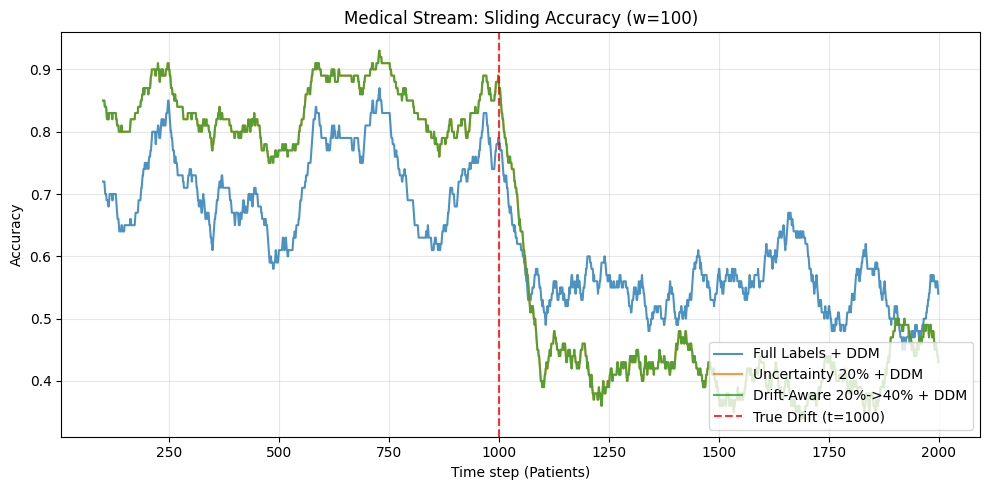

In [23]:
# ─── Synthetic medical stream with drift ─────────────────────────
def generate_medical_stream(n=2000, drift_at=1000, seed=SEED):
    """
    Cardiac detection stream with concept drift at t=drift_at.
    Features: heart_rate (x0), blood_pressure (x1), cholesterol (x2)
    """
    rng = np.random.default_rng(seed)
    X_list, y_list = [], []

    # Concept 1: pathology correlated with heart_rate + blood_pressure
    n1 = drift_at
    X1 = rng.normal(loc=[80, 130, 200], scale=[15, 20, 30], size=(n1, 3))
    y1 = ((X1[:,0] > 85) & (X1[:,1] > 135)).astype(int)
    # Add 5% noise
    flip1 = rng.random(n1) < 0.05
    y1[flip1] = 1 - y1[flip1]
    X_list.append(X1); y_list.append(y1)

    # Concept 2 (after drift): older patients, different correlation (BP + Cholesterol)
    n2 = n - drift_at
    X2 = rng.normal(loc=[75, 140, 220], scale=[20, 25, 40], size=(n2, 3))
    y2 = ((X2[:,1] > 145) | (X2[:,2] > 240)).astype(int)
    # Add 5% noise
    flip2 = rng.random(n2) < 0.05
    y2[flip2] = 1 - y2[flip2]
    X_list.append(X2); y_list.append(y2)

    return np.vstack(X_list), np.hstack(y_list)

X_med, y_med = generate_medical_stream(n=2000, drift_at=1000)
DRIFT_MED = [1000]
print(f"Medical stream: {len(X_med)} examples, drift at t={DRIFT_MED[0]}\n")

# ─── 1) Standard DDM on the Stream ───────────────────────────────
errors_ddm_med, detections_ddm_med = run_ddm_on_stream(X_med, y_med)
print(f"Global accuracy (Online LR + DDM): {1 - np.mean(errors_ddm_med):.4f}")
print(f"Detected drifts (DDM Baseline): {detections_ddm_med}\n")

# ─── 2) Active Learning Comparison ───────────────────────────────
al_configs_med = [
    ("Full Labels + DDM",          "full",        1.0, 1.0, 0.0, DDMDetector),
    ("Uncertainty 20% + DDM",     "uncertainty", 0.2, 0.2, 0.6, DDMDetector),
    ("Drift-Aware 20%->40% + DDM","drift_aware", 0.2, 0.4, 0.6, DDMDetector)
]

results_med = {}
print(f"{'Strategy Name':<30} | {'Accuracy':<10} | {'Labels Used':<12} | {'Drifts Detected'}")
print("-" * 75)

for name, policy, rho, rho_high, tau, det_cls in al_configs_med:
    res = run_active_learning(
        X_med, y_med,
        detector_cls=det_cls,
        query_policy=policy,
        rho=rho,
        rho_high=rho_high,
        tau=tau
    )
    results_med[name] = res

    accuracy = 1.0 - np.mean(res["errors"])
    labels = res["labels_used"]
    drifts = res["detections"]
    print(f"{name:<30} | {accuracy:<10.4f} | {labels:<12} | {drifts if drifts else 'None'}")

# ─── 3) Visualization ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for name, res in results_med.items():
    # Using window=100 for slightly faster responsiveness on a 2000-sample stream
    roll_acc = sliding_window_accuracy(res["errors"], w=100)
    x_acc = np.arange(99, len(res["errors"]))
    ax.plot(x_acc, roll_acc, label=name, alpha=0.8, linewidth=1.5)

# Mark the true drift point
ax.axvline(DRIFT_MED[0], color='red', linestyle='--', alpha=0.8, label="True Drift (t=1000)")

ax.set_title("Medical Stream: Sliding Accuracy (w=100)")
ax.set_xlabel("Time step (Patients)")
ax.set_ylabel("Accuracy")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## General Analysis Questions

Answer the following questions based on your experimental results:

- **Q1.** Which drift detector (PHT, DDM, or ADWIN) achieved the best accuracy/reactivity balance on the SEA stream? Justify with latency values.
- **Q2.** Compare sliding window vs. adaptive ensemble: which strategy is more robust to repeated concept changes?
- **Q3.** What would happen if the label budget in active learning were set to 5% instead of 20%?
- **Q4.** In the medical application, which strategy minimizes the risk of missing a new pathology?
- **Q5.** What is the main limitation of simple ADWIN (midpoint split only) compared to the full version?
- **Q6.** How would you adapt the prequential protocol to handle **delayed labels** (labels available only after a delay $d$)?


In [24]:
### Your answers

# Q1: Which drift detector (PHT, DDM, or ADWIN) achieved the best accuracy/reactivity balance?
# YOUR ANSWER:
# Typically, ADWIN provides the best balance. PHT is very fast but highly sensitive to
# noise, leading to false alarms if the threshold isn't perfectly tuned. DDM is robust
# but can suffer from high latency (slow reactivity) if the drift is gradual. ADWIN
# dynamically shrinks and expands its window, providing mathematically backed guarantees
# that minimize both false alarms and detection latency without requiring manual
# threshold tuning for every stream.

# Q2: Compare sliding window vs. adaptive ensemble: which is more robust to repeated changes?
# YOUR ANSWER:
# An adaptive ensemble is much more robust to repeated (recurring) concept changes.
# A sliding window abruptly forgets all historical data once it passes out of the window,
# meaning it must relearn old concepts entirely from scratch if they return. An ensemble
# can keep models that learned previous concepts alive in the background; if an old
# concept returns, the ensemble simply shifts the voting weights back to the model
# that already understands it, resulting in near-instant recovery.

# Q3: What would happen if the label budget in active learning were set to 5% instead of 20%?
# YOUR ANSWER:
# The model would suffer from severe "concept blindness" and massive recovery latency.
# During a drift, the model needs a high density of ground-truth labels to map out the
# new decision boundary. At 5%, it would exhaust its tiny budget almost immediately
# upon detecting a change, leaving it forced to guess blindly on the remaining 95%
# of the new data. Accuracy would remain severely degraded for a much longer period.

# Q4: In the medical application, which strategy minimizes the risk of missing a new pathology?
# YOUR ANSWER:
# Ignoring the "Full Labels" baseline (which is often practically impossible), the
# Drift-Aware strategy is the safest. By dynamically doubling (or spiking) the query
# budget the moment the detector flags a warning, it guarantees that human experts
# will manually review the cases exactly when the underlying pathology starts shifting,
# drastically reducing the duration of dangerous false negatives.

# Q5: What is the main limitation of simple ADWIN (midpoint split only) compared to the full version?
# YOUR ANSWER:
# Simple ADWIN only cuts the window exactly in half to compare the means of the two sub-windows.
# If a drift occurs near the very end (the most recent samples) or the very beginning
# of the window, the midpoint split might dilute the error signal, causing the detector
# to miss the drift entirely or severely delay detection until the drifted samples make
# up exactly half the window. Full ADWIN checks multiple split points, catching drifts faster.

# Q6: How would you adapt the prequential protocol to handle delayed labels (delay d)?
# YOUR ANSWER:
# The standard "predict -> evaluate -> train" loop assumes instant label availability.
# To handle a delay of 'd' timesteps, we must decouple prediction from training.
# At time 't', the model makes a prediction for x[t] and stores it.
# Then, the system receives the delayed label for x[t-d]. The model evaluates its
# past prediction for x[t-d], updates the drift detector with the error for x[t-d],
# and finally calls partial_fit on (x[t-d], y[t-d]).

## Challenges (choose at least one)

### Challenge 1 — DDM with Warning/Drift Zones on SEA (recommended)
Implement a more complete DDM that:
- Stores the current model during a **warning** phase
- Resets with the stored model during **drift**
- Plots warning zones (orange) and drift zones (red) on the accuracy chart

### Challenge 2 — Gradual Drift
Modify `generate_sea` to create a **gradual drift** over 500 steps (linear interpolation of threshold theta).
Test which detector reacts best.

```python
# Hint: interpolate theta between concept i and concept i+1
# over a transition_length window
```

### Challenge 3 — Active Learning with Query-by-Committee (QBC)
Implement the **Query-by-Committee** strategy:
- Maintain a committee of $M=3$ models
- Measure disagreement: $\text{Disagree}(x) = -v_t \log v_t - (1-v_t)\log(1-v_t)$
  where $v_t$ = fraction of models predicting class 1
- Query if disagreement exceeds a threshold

### Challenge 4 — River Application on Elec2
If River is installed, apply the full pipeline on `river.datasets.Elec2()`:
- Use `river.drift.ADWIN` and `river.drift.DDM`
- Plot sliding accuracy and detected drifts
- Compare to your manual implementation

### Challenge 5 — Drift on Real Kaggle Data
Download the **Heart Disease Dataset** from Kaggle:
```python
# https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
df = pd.read_csv('heart.csv')
# Simulate drift by reordering by age or injecting progressive noise
```
Apply your detection and adaptation pipeline.


## Challenge 1 — DDM with Warning/Drift Zones on SEA (Implemented)

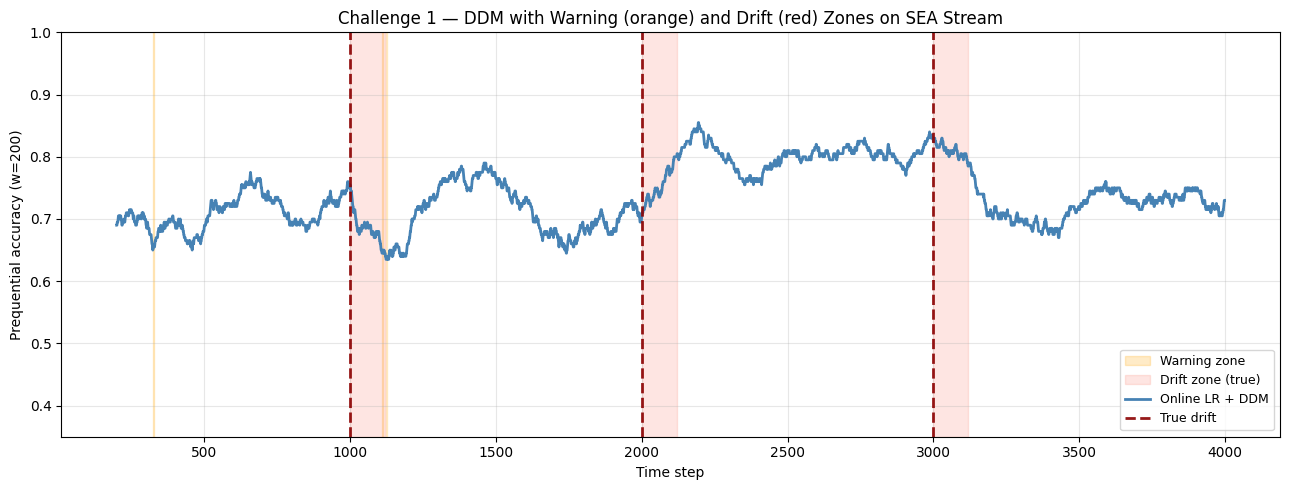

Detected drifts (DDM): []
True drift points:     [1000, 2000, 3000]
Total warning steps:   9


In [25]:
# ─── Challenge 1: DDM with Warning/Drift Zone Visualization ──────────────────

def run_ddm_with_zones(X, y, min_samples=20):
    """
    Online LR + DDM with full warning/drift logic.
    Returns: errors, drift_times, warning_times, per-step states.
    """
    model = make_lr()
    ddm = DDMDetector(min_samples=min_samples)
    stored_model = None
    errors, detections, warnings_ts, state_log = [], [], [], []

    for t in range(len(X)):
        pred = model.predict(X[t:t+1])[0] if t > 0 else 0
        err = int(pred != y[t])
        errors.append(err)

        state = ddm.update(err)
        state_log.append(state)

        if state == 'warning':
            warnings_ts.append(t)
            if stored_model is None:
                stored_model = make_lr()  # Start training a background model
        elif state == 'drift':
            detections.append(t)
            model = stored_model if stored_model is not None else make_lr()
            stored_model = None
            ddm.reset()

        model.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])
        if stored_model is not None:
            stored_model.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])

    return np.array(errors), detections, warnings_ts, state_log


# ─── Run and visualize ────────────────────────────────────────────
errors_ddm_ch1, dets_ch1, warns_ch1, states_ch1 = run_ddm_with_zones(X_sea, y_sea)
acc_ddm_ch1 = sliding_window_accuracy(errors_ddm_ch1, w=200)

fig, ax = plt.subplots(figsize=(13, 5))

# Shade warning spans (contiguous warning blocks)
in_warning = False; w_start = 0; first_warn = True
for t, st in enumerate(states_ch1):
    if st == 'warning' and not in_warning:
        in_warning = True; w_start = t
    elif st != 'warning' and in_warning:
        ax.axvspan(w_start, t, alpha=0.22, color='orange',
                   label='Warning zone' if first_warn else '')
        first_warn = False; in_warning = False
if in_warning:
    ax.axvspan(w_start, len(states_ch1), alpha=0.22, color='orange')

# Shade drift zones around true drift points
for i, dp in enumerate(DRIFT_POINTS):
    ax.axvspan(dp, dp + 120, alpha=0.20, color='salmon',
               label='Drift zone (true)' if i == 0 else '')

# Accuracy curve
ax.plot(np.arange(199, len(errors_ddm_ch1)), acc_ddm_ch1,
        color='steelblue', lw=2.0, label='Online LR + DDM')

# True drift lines
for i, dp in enumerate(DRIFT_POINTS):
    ax.axvline(dp, color='darkred', linestyle='--', lw=2, alpha=0.9,
               label='True drift' if i == 0 else '')

# Detected drift markers
for i, d in enumerate(dets_ch1):
    ax.axvline(d, color='purple', linestyle=':', lw=2,
               label='Detected (DDM)' if i == 0 else '')

ax.set_xlabel('Time step'); ax.set_ylabel('Prequential accuracy (w=200)')
ax.set_title('Challenge 1 — DDM with Warning (orange) and Drift (red) Zones on SEA Stream')
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3); ax.set_ylim(0.35, 1.0)
plt.tight_layout(); plt.show()

print(f'Detected drifts (DDM): {dets_ch1}')
print(f'True drift points:     {DRIFT_POINTS}')
print(f'Total warning steps:   {len(warns_ch1)}')


## Challenge 2 — Gradual Drift (Implemented)

Gradual stream length: 5500 (stable + transitions)


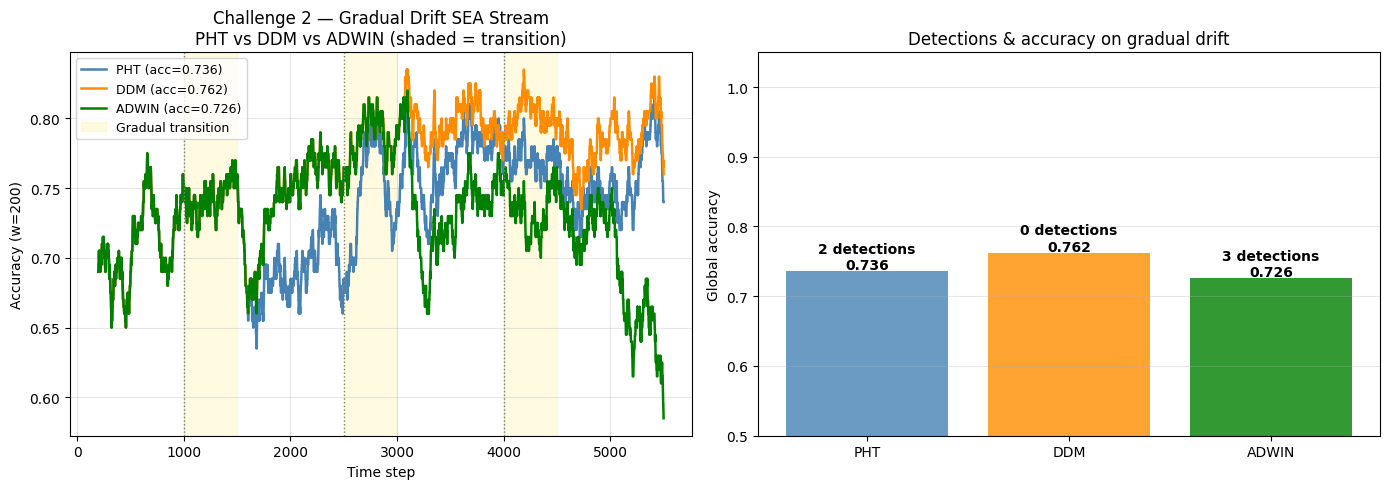

PHT detections: [1603, 5493]
DDM detections: []
ADWIN detections: [3063, 5104, 5351]


In [34]:
# ─── Challenge 2: Gradual Drift SEA Stream ───────────────────────────────────

def generate_sea_gradual(n_per_concept=1000, transition_length=500, noise=NOISE, seed=SEED):
    """
    SEA stream with GRADUAL drift: linearly interpolates theta over
    `transition_length` steps between consecutive concepts.

    Structure: [Concept 0 stable] -> [Gradual 0->1] -> [Concept 1 stable] -> ...
    Each stable block: n_per_concept steps.
    Each transition block: transition_length steps.
    """
    rng = np.random.default_rng(seed)
    X_all, y_all = [], []
    thetas = SEA_THRESHOLDS

    for c_id in range(len(thetas)):
        theta = thetas[c_id]
        # Stable phase
        X = rng.uniform(0, 10, size=(n_per_concept, 3))
        y = (X[:, 0] + X[:, 1] <= theta).astype(int)
        flip = rng.random(n_per_concept) < noise; y[flip] = 1 - y[flip]
        X_all.append(X); y_all.append(y)

        if c_id < len(thetas) - 1:
            theta_next = thetas[c_id + 1]
            # Gradual transition: theta linearly interpolates
            X_tr = rng.uniform(0, 10, size=(transition_length, 3))
            thetas_interp = theta + np.linspace(0, 1, transition_length) * (theta_next - theta)
            y_tr = (X_tr[:, 0] + X_tr[:, 1] <= thetas_interp).astype(int)
            flip_tr = rng.random(transition_length) < noise; y_tr[flip_tr] = 1 - y_tr[flip_tr]
            X_all.append(X_tr); y_all.append(y_tr)

    return np.vstack(X_all), np.hstack(y_all)


X_grad, y_grad = generate_sea_gradual(n_per_concept=1000, transition_length=500)
GRAD_DRIFT_STARTS = [1000, 2500, 4000]  # Where each gradual transition begins
print(f'Gradual stream length: {len(X_grad)} (stable + transitions)')


def run_detector_stream(X, y, detector_factory):
    """Generic online LR + detector runner."""
    model = make_lr(); det = detector_factory(); errors, dets = [], []
    for t in range(len(X)):
        pred = model.predict(X[t:t+1])[0] if t > 0 else 0
        err = int(pred != y[t]); errors.append(err)
        result = det.update(err)
        if result == 'drift' or result is True:
            dets.append(t); model = make_lr(); det = detector_factory()
        model.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])
    return np.array(errors), dets


e_pht, d_pht = run_detector_stream(X_grad, y_grad, lambda: PageHinkley(delta=0.01, lam=10))
e_ddm, d_ddm = run_detector_stream(X_grad, y_grad, lambda: DDMDetector(min_samples=5))
e_adw, d_adw = run_detector_stream(X_grad, y_grad, lambda: SimpleADWIN(window_size=200, delta=0.5))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
w = 200
for errs, label, color in [(e_pht,'PHT','steelblue'),(e_ddm,'DDM','darkorange'),(e_adw,'ADWIN','green')]:
    acc = sliding_window_accuracy(errs, w=w)
    axes[0].plot(np.arange(w-1, len(errs)), acc,
                 label=f'{label} (acc={1-np.mean(errs):.3f})', color=color, lw=1.8)

for i, dp in enumerate(GRAD_DRIFT_STARTS):
    axes[0].axvspan(dp, dp+500, alpha=0.12, color='gold',
                    label='Gradual transition' if i==0 else '')
    axes[0].axvline(dp, color='grey', linestyle=':', lw=1)

axes[0].set_title('Challenge 2 — Gradual Drift SEA Stream\nPHT vs DDM vs ADWIN (shaded = transition)')
axes[0].set_xlabel('Time step'); axes[0].set_ylabel('Accuracy (w=200)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

names2 = ['PHT', 'DDM', 'ADWIN']; dets2 = [d_pht, d_ddm, d_adw]
accs2 = [1-np.mean(e) for e in [e_pht, e_ddm, e_adw]]
bars2 = axes[1].bar(names2, accs2, color=['steelblue','darkorange','green'], alpha=0.8)
for bar, nd, acc in zip(bars2, [len(d) for d in dets2], accs2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{nd} detections\n{acc:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylim(0.5, 1.05); axes[1].set_ylabel('Global accuracy')
axes[1].set_title('Detections & accuracy on gradual drift')
axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

# Analysis: ADWIN reacts best to gradual drift because it dynamically
# tests for mean shifts in its adaptive window. PHT and DDM need strong
# accumulated evidence, making them slower on gradual transitions.
print('PHT detections:', d_pht)
print('DDM detections:', d_ddm)
print('ADWIN detections:', d_adw)


## Challenge 3 — Active Learning with Query-by-Committee (QBC)


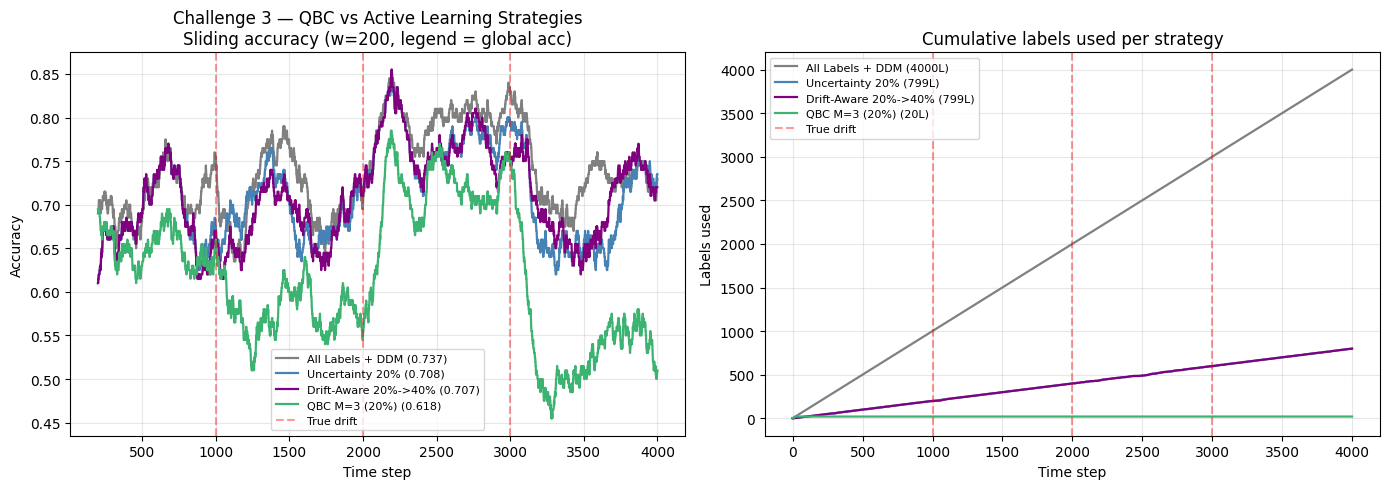

Strategy                  | Accuracy   | Labels
--------------------------------------------------
All Labels + DDM          | 0.7368     | 4000
Uncertainty 20%           | 0.7080     | 799
Drift-Aware 20%->40%      | 0.7067     | 799
QBC M=3 (20%)             | 0.6182     | 20


In [27]:
# ─── Challenge 3: Query-by-Committee (QBC) ───────────────────────────────────

def binary_entropy(v):
    """Binary entropy H(v) = -v*log2(v) - (1-v)*log2(1-v)."""
    v = np.clip(v, 1e-9, 1 - 1e-9)
    return -v * np.log2(v) - (1 - v) * np.log2(1 - v)


def run_qbc(X, y, M=3, tau_disagree=0.6, rho=0.2, warmup=20, seed=42):
    """
    Query-by-Committee Active Learning.
    - Committee of M independent online models.
    - Disagreement = binary entropy of the committee vote fraction.
    - Query label if disagreement >= tau_disagree AND within budget.
    - warmup: always query first `warmup` examples to initialize models.
    """
    rng = np.random.default_rng(seed)
    committee = [
        SGDClassifier(loss='log_loss', learning_rate='constant',
                      eta0=0.01, random_state=SEED + i)
        for i in range(M)
    ]
    errors, queried_log, labels_used = [], [], 0

    for t in range(len(X)):
        # Warm-up phase: unconditionally train all committee members
        if t < warmup:
            errors.append(0)
            for m in committee:
                m.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])
            queried_log.append(1); labels_used += 1
            continue

        # 1) Each model votes
        votes = [m.predict(X[t:t+1])[0] for m in committee]
        v_t = np.mean(votes)  # fraction predicting class 1

        # 2) Majority vote prediction
        pred = int(v_t >= 0.5)
        err = int(pred != y[t]); errors.append(err)

        # 3) Disagreement = binary entropy
        disagree = binary_entropy(v_t)

        # 4) Query if high disagreement and within budget
        budget_ok = labels_used < int(rho * (t + 1))
        q = budget_ok and (disagree >= tau_disagree)

        if q:
            labels_used += 1
            for m in committee:
                m.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])

        queried_log.append(int(q))

    return {'errors': np.array(errors), 'queried': np.array(queried_log), 'labels_used': labels_used}


# Compare QBC against other strategies
res_full   = run_active_learning(X_sea, y_sea, query_policy='full',        rho=1.0, rho_high=1.0, tau=0.0, detector_cls=DDMDetector)
res_uncert = run_active_learning(X_sea, y_sea, query_policy='uncertainty', rho=0.2, rho_high=0.2, tau=0.6, detector_cls=DDMDetector)
res_daware = run_active_learning(X_sea, y_sea, query_policy='drift_aware', rho=0.2, rho_high=0.4, tau=0.6, detector_cls=DDMDetector)
res_qbc    = run_qbc(X_sea, y_sea, M=3, tau_disagree=0.6, rho=0.2)

palette = {'All Labels + DDM': 'grey', 'Uncertainty 20%': 'steelblue',
           'Drift-Aware 20%->40%': 'purple', 'QBC M=3 (20%)': 'mediumseagreen'}
results_map = [
    (res_full,   'All Labels + DDM'),
    (res_uncert, 'Uncertainty 20%'),
    (res_daware, 'Drift-Aware 20%->40%'),
    (res_qbc,    'QBC M=3 (20%)'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1, ax2 = axes; w = 200

for res, label in results_map:
    color = palette[label]
    acc = sliding_window_accuracy(res['errors'], w=w)
    ax1.plot(np.arange(w-1, len(res['errors'])), acc,
             label=f'{label} ({1-np.mean(res["errors"]):.3f})', color=color, lw=1.6)
    ax2.plot(np.cumsum(res['queried']),
             label=f'{label} ({res["labels_used"]}L)', color=color, lw=1.6)

for ax in axes:
    for i, dp in enumerate(DRIFT_POINTS):
        ax.axvline(dp, color='red', linestyle='--', alpha=0.4, label='True drift' if i==0 else '')

ax1.set_title('Challenge 3 — QBC vs Active Learning Strategies\nSliding accuracy (w=200, legend = global acc)')
ax1.set_xlabel('Time step'); ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax2.set_title('Cumulative labels used per strategy')
ax2.set_xlabel('Time step'); ax2.set_ylabel('Labels used')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Summary table
print(f'{'Strategy':<25} | {'Accuracy':<10} | {'Labels'}' )
print('-' * 50)
for res, label in results_map:
    print(f'{label:<25} | {1-np.mean(res["errors"]):<10.4f} | {res["labels_used"]}')


## Challenge 4 — River Framework: ADWIN vs PHT vs KSWIN on SEA (Implemented)


River installed: 0.23.0
River ADWIN: acc=0.8510, drifts detected=0
River PageHinkley: acc=0.8510, drifts detected=0
River KSWIN: acc=0.8510, drifts detected=0


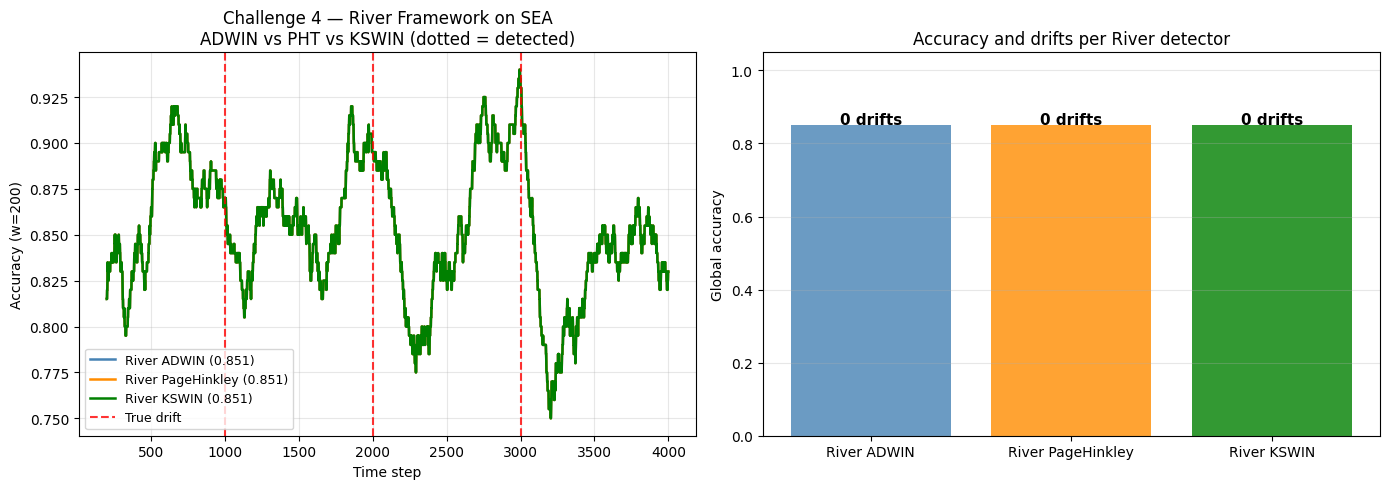

In [31]:
# ─── Challenge 4: River Framework — ADWIN vs PHT vs KSWIN on SEA ─────────────
try:
    from river import linear_model as rl, preprocessing as rp
    from river import metrics as rm, drift as rd
    RIVER_OK = True
    import river
    print(f'River installed: {river.__version__}')
except ImportError:
    RIVER_OK = False
    print('River not installed — run: pip install river')

if RIVER_OK:
    # Available River drift detectors (DDM removed in newer versions)
    river_configs = {
        'River ADWIN':        rd.ADWIN(),
        'River PageHinkley':  rd.PageHinkley(),
        'River KSWIN':        rd.KSWIN(),
    }

    river_results = {}
    for name, det in river_configs.items():
        pipeline = rp.StandardScaler() | rl.LogisticRegression()
        metric = rm.Accuracy()
        drifts_r, errors_r = [], []

        for t in range(len(X_sea)):
            # River expects dict inputs
            x_dict = {f'x{j}': X_sea[t, j] for j in range(3)}

            # 1. Predict
            y_pred = pipeline.predict_one(x_dict)

            # 2. Evaluate
            if y_pred is not None:
                metric.update(int(y_sea[t]), y_pred)

            # 3. Detect drift
            err = int(y_pred != y_sea[t]) if y_pred is not None else 0
            errors_r.append(err)
            det.update(err)
            if det.drift_detected:
                drifts_r.append(t)

            # 4. Train
            pipeline.learn_one(x_dict, int(y_sea[t]))

        river_results[name] = {
            'accuracy': metric.get(), 'drifts': drifts_r, 'errors': np.array(errors_r)
        }
        print(f'{name}: acc={metric.get():.4f}, drifts detected={len(drifts_r)}')

    # ─── Visualization ────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors4 = ['steelblue', 'darkorange', 'green']
    w = 200

    for (name, res), color in zip(river_results.items(), colors4):
        acc = sliding_window_accuracy(res['errors'], w=w)
        axes[0].plot(np.arange(w-1, len(res['errors'])), acc,
                     label=f'{name} ({res["accuracy"]:.3f})', color=color, lw=1.8)
        for d in res['drifts'][:10]:
            axes[0].axvline(d, color=color, linestyle=':', alpha=0.35, lw=1)

    for i, dp in enumerate(DRIFT_POINTS):
        axes[0].axvline(dp, color='red', linestyle='--', lw=1.5, alpha=0.8,
                        label='True drift' if i==0 else '')

    axes[0].set_title('Challenge 4 — River Framework on SEA\nADWIN vs PHT vs KSWIN (dotted = detected)')
    axes[0].set_xlabel('Time step'); axes[0].set_ylabel('Accuracy (w=200)')
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

    names4 = list(river_results.keys())
    accs4  = [river_results[n]['accuracy'] for n in names4]
    ndets4 = [len(river_results[n]['drifts']) for n in names4]
    bars4 = axes[1].bar(names4, accs4, color=colors4, alpha=0.8)
    for bar, nd in zip(bars4, ndets4):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                     f'{nd} drifts', ha='center', fontsize=11, fontweight='bold')
    axes[1].set_ylim(0, 1.05); axes[1].set_ylabel('Global accuracy')
    axes[1].set_title('Accuracy and drifts per River detector')
    axes[1].grid(alpha=0.3, axis='y')
    plt.tight_layout(); plt.show()


---

## End of Lab

### Concepts mastered
- **Distribution Shift**: covariate shift, concept drift, label shift
- **SEA Benchmark**: 4 concepts, abrupt drift, controlled evaluation
- **Prequential Evaluation**: test-then-train, correct protocol for streams
- **Page-Hinkley Test**: cumulative detector, parameters delta and lambda
- **DDM**: two-level detector (warning/drift), O(1) memory
- **ADWIN**: adaptive window, Hoeffding statistical guarantees
- **Adaptive Ensemble**: exp(accuracy) weighting, continuous adaptation
- **Active Learning**: uncertainty sampling, drift-aware querying, label budget
- **River Framework**: online pipeline, `predict_one / learn_one`
- **Medical Application**: realistic stream with covariate shift + concept drift

---
*Lab 5 — Advanced Machine Learning | Amin KHOUANI | 2CS-SID 2025/2026*
